<a href="https://colab.research.google.com/github/williamtheodoruswijaya/semantix/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [139]:
%%capture

!pip install torch torchvision torchaudio
!pip install segmentation-models-pytorch timm
!pip install albumentations opencv-python pillow pandas scikit-learn tqdm

## Import Libraries

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import cv2

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import os
import zipfile
import random
import json
from pathlib import Path
from tqdm import tqdm

> Seeding

In [141]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

## Import Dataset

- Unzip dataset

In [142]:
os.makedirs("/content/flopwd_data", exist_ok=True)

with zipfile.ZipFile("/content/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025).zip", "r") as zip_ref:
  zip_ref.extractall("/content/flopwd_data")

- Get Images

In [143]:
raw_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images").glob("*")))
mask_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks").glob("*")))
labels_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Image_labels_Binary Classification Task.csv")
reg_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Mask_foreground_percentages_Regression Task.csv")

In [144]:
labels_df = pd.read_csv(labels_csv)
reg_df = pd.read_csv(reg_csv)

In [145]:
labels_df.head()

,image name,Presence of plastic waste?
0,img1.jpg,yes
1,img2.jpg,yes
2,img3.jpg,yes
3,img4.jpg,yes
4,img5.jpg,yes


In [146]:
reg_df.head()

,image name,plastic waste accumulation (in percentage)
0,img1.jpg,0.08
1,img2.jpg,0.03
2,img3.jpg,0.38
3,img4.jpg,0.20
4,img5.jpg,0.18


### Transform Dataset

In [147]:
labels_df = labels_df.rename(columns={
    "image name": "image_name",
    "Presence of plastic waste?": "presence"
})

reg_df = reg_df.rename(columns={
    "image name": "image_name",
    "plastic waste accumulation (in percentage)": "fg_pct"
})

df = labels_df.merge(reg_df, on="image_name", how="inner")

df["image_path"] = df["image_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images") / x))
df["mask_name"] = df["image_name"].str.replace(".jpg", "_mask.png", regex=False)
df["mask_path"] = df["mask_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks") / x))

df["presence"] = df["presence"].astype(str).str.strip().str.lower()
df["has_plastic"] = (df["presence"] == "yes").astype(int)

df.head()

,image_name,presence,fg_pct,image_path,mask_name,mask_path,has_plastic
0,img1.jpg,yes,0.08,/content/flopwd_data/Dal Lake Floating Plastic...,img1_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
1,img2.jpg,yes,0.03,/content/flopwd_data/Dal Lake Floating Plastic...,img2_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
2,img3.jpg,yes,0.38,/content/flopwd_data/Dal Lake Floating Plastic...,img3_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
3,img4.jpg,yes,0.20,/content/flopwd_data/Dal Lake Floating Plastic...,img4_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
4,img5.jpg,yes,0.18,/content/flopwd_data/Dal Lake Floating Plastic...,img5_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1


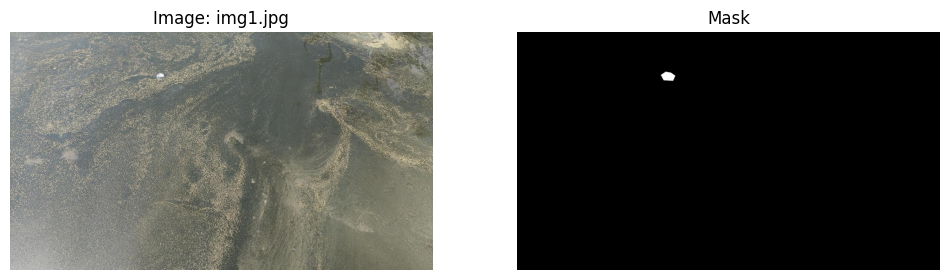

In [148]:
row = df.iloc[0]
image = cv2.imread(row["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Image: {row['image_name']}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

## Data Splitting (70:15:15)

In [149]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["has_plastic"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["has_plastic"]
)

In [150]:
# reset
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 1445
Val  : 256
Test : 301


## Data Preprocessing

### Image Augmentation

In [151]:
IMAGE_HEIGHT = 448
IMAGE_WIDTH = 800

In [152]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

In [153]:
# transform only training and validation images

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.OneOf([
        A.ElasticTransform(alpha=1, sigma=50, p=0.5),
        A.GridDistortion(p=0.5),
    ], p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    A.CoarseDropout(
        num_holes_range=(1, 8),
        hole_height_range=(16, 32),
        hole_width_range=(16, 32),
        p=0.3
    ),
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Image Preprocessing (Class & Dataloader)

In [154]:
class Dataset(Dataset):
  def __init__(self, dataframe, transforms=None):
    self.dataframe = dataframe
    self.transforms = transforms

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]
    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.float32) # changes from 0/255 into 0.0/1.0 (0=background, 1=plastic)

    if self.transforms:
      transformed = self.transforms(image=image, mask=mask)
      image = transformed["image"]
      mask = transformed["mask"]

    mask = mask.unsqueeze(0) # add channel [1, H, W]

    return image, mask

In [155]:
train_dataset = Dataset(train_df, transforms=train_transform)
val_dataset = Dataset(val_df, transforms=val_transform)
test_dataset = Dataset(test_df, transforms=val_transform)

In [156]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

## Modelling

In [157]:
%%capture

model = smp.Unet(
    encoder_name="tu-convnextv2_tiny.fcmae_ft_in22k_in1k",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

## Training

#### Training Hyperparameter

In [158]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEVICE

'cuda'

In [159]:
model = model.to(DEVICE)

#### Loss Function

##### Pos Weight Estimation for Class Imbalance Handlign

For Give more loss if positive pixel are predicted falsely (FP)

In [160]:
pos_pixels = 0
neg_pixels = 0

# step 1: sampling sebanyak 200
subset = train_df.sample(min(200, len(train_df)), random_state=42)

for _, row in subset.iterrows():
  mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
  mask = (mask > 127).astype(np.uint8)

  pos_pixels += mask.sum()
  neg_pixels += mask.size - mask.sum()

pos_weight = neg_pixels / max(pos_pixels, 1)

pos_weight

np.float64(17.441991871195814)

##### BCE

Loss function for Clasification per pixel

In [161]:
bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=DEVICE)
)

##### DICE

Loss function for Mask Overlapping

In [162]:
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

#####  Combine

In [163]:
def combined_loss(pred_mask, true_mask, dice_weight=0.6, bce_weight=0.4):
  d_loss = dice_loss(pred_mask, true_mask)
  b_loss = bce_loss(pred_mask, true_mask)
  return 0.7 * d_loss + 0.3 * b_loss

#### Optimizer

In [164]:
encoder_params = list(model.encoder.parameters())
decoder_params = list(model.decoder.parameters()) + list(model.segmentation_head.parameters())

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": 1e-5},
    {"params": decoder_params, "lr": 3e-4},
], weight_decay=1e-4)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

/tmp/ipykernel_4688/2321429026.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


#### Metric

In [165]:
def apply_sigmoid(x):
  return torch.sigmoid(x)

In [166]:
def binarize_mask(prob_mask, threshold=0.5):
  return (prob_mask > threshold).float()

In [167]:
def compute_stats(preds, targets, eps=1e-7):
  preds = preds.float()
  targets = targets.float()

  tp = (preds * targets).sum(dim=(1,2,3))
  fp = (preds * (1 - targets)).sum(dim=(1,2,3))
  fn = ((1 - preds) * targets).sum(dim=(1,2,3))

  iou = (tp + eps) / (tp + fp + fn + eps)
  dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
  precision = (tp + eps) / (tp + fp + eps)
  recall = (tp + eps) / (tp + fn + eps)

  return {
      "iou": iou.mean().item(),
      "dice": dice.mean().item(),
      "precision": precision.mean().item(),
      "recall": recall.mean().item()
  }

In [168]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(images)
            loss = combined_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return running_loss / len(loader)

In [169]:
def validate_one_epoch(model, loader, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    iou_scores = []
    dice_scores = []
    precision_scores = []
    recall_scores = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)
            loss = combined_loss(logits, masks)

            probs = apply_sigmoid(logits)
            preds = binarize_mask(probs, threshold=threshold)

            stats = compute_stats(preds, masks)

            running_loss += loss.item()
            iou_scores.append(stats["iou"])
            dice_scores.append(stats["dice"])
            precision_scores.append(stats["precision"])
            recall_scores.append(stats["recall"])

    return {
        "loss": running_loss / len(loader),
        "iou": np.mean(iou_scores),
        "dice": np.mean(dice_scores),
        "precision": np.mean(precision_scores),
        "recall": np.mean(recall_scores)
    }

In [170]:
def find_best_threshold(model, loader, device):
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_threshold = 0.5
    best_dice = -1

    model.eval()

    all_probs = []
    all_masks = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Collecting val probs", leave=False):
            images = images.to(device)
            logits = model(images)
            probs = torch.sigmoid(logits).cpu()
            all_probs.append(probs)
            all_masks.append(masks.cpu())

    all_probs = torch.cat(all_probs, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    for threshold in thresholds:
        preds = (all_probs > threshold).float()
        stats = compute_stats(preds, all_masks)
        if stats["dice"] > best_dice:
            best_dice = stats["dice"]
            best_threshold = threshold

    return best_threshold, best_dice

#### Training

In [171]:
EPOCHS = 30
PATIENCES = 5

In [ ]:
best_val_dice = -1
best_model_path = "/content/best_flopwd_unetplusplus.pth"

history = []
counter = 0

In [172]:
for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)

    best_threshold, _ = find_best_threshold(model, val_loader, DEVICE)
    val_metrics = validate_one_epoch(model, val_loader, DEVICE, threshold=best_threshold)

    print(f"Train Loss   : {train_loss:.4f}")
    print(f"Val Loss     : {val_metrics['loss']:.4f}")
    print(f"Val IoU      : {val_metrics['iou']:.4f}")
    print(f"Val Dice     : {val_metrics['dice']:.4f}")
    print(f"Val Precision: {val_metrics['precision']:.4f}")
    print(f"Val Recall   : {val_metrics['recall']:.4f}")
    print(f"Best Threshold: {best_threshold:.2f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_iou": val_metrics["iou"],
        "val_dice": val_metrics["dice"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "best_threshold": float(best_threshold)
    })

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")
        counter = 0
    else:
        counter += 1
        print(f"No improvement. Patience counter: {counter}/{PATIENCES}")

    if counter >= PATIENCES:
        print("Early stopping triggered.")
        break


Epoch [1/30]


Training:   0%|          | 0/362 [00:00<?, ?it/s]/tmp/ipykernel_4688/2539086823.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Train Loss   : 0.6420
Val Loss     : 0.4619
Val IoU      : 0.5069
Val Dice     : 0.6063
Val Precision: 0.6806
Val Recall   : 0.6990
Best Threshold: 0.90
Best model saved.

Epoch [2/30]


Train Loss   : 0.4715
Val Loss     : 0.4295
Val IoU      : 0.5157
Val Dice     : 0.6186
Val Precision: 0.6375
Val Recall   : 0.7804
Best Threshold: 0.90
Best model saved.

Epoch [3/30]


Train Loss   : 0.4035
Val Loss     : 0.3628
Val IoU      : 0.5597
Val Dice     : 0.6627
Val Precision: 0.6873
Val Recall   : 0.7835
Best Threshold: 0.65
Best model saved.

Epoch [4/30]


...

Train Loss   : 0.2119
Val Loss     : 0.2500
Val IoU      : 0.6931
Val Dice     : 0.7860
Val Precision: 0.8046
Val Recall   : 0.8340
Best Threshold: 0.85
Best model saved.

Epoch [27/30]


Train Loss   : 0.2030
Val Loss     : 0.2503
Val IoU      : 0.6852
Val Dice     : 0.7768
Val Precision: 0.7844
Val Recall   : 0.8455
Best Threshold: 0.90
No improvement. Patience counter: 1/8

Epoch [28/30]


Train Loss   : 0.2069
Val Loss     : 0.2383
Val IoU      : 0.7075
Val Dice     : 0.7987
Val Precision: 0.8272
Val Recall   : 0.8286
Best Threshold: 0.90
Best model saved.

Epoch [29/30]


Train Loss   : 0.1937
Val Loss     : 0.2627
Val IoU      : 0.6936
Val Dice     : 0.7854
Val Precision: 0.7899
Val Recall   : 0.8510
Best Threshold: 0.45
No improvement. Patience counter: 1/8

Epoch [30/30]


Train Loss   : 0.1924
Val Loss     : 0.2493
Val IoU      : 0.6767
Val Dice     : 0.7702
Val Precision: 0.7545
Val Recall   : 0.8690
Best Threshold: 0.90
No improvement. Patience counter: 2/8


##### Training History

In [173]:
history_df = pd.DataFrame(history)
history_df.to_csv("/content/flopwd_training_history.csv", index=False)
history_df.tail()

,epoch,train_loss,val_loss,val_iou,val_dice,val_precision,val_recall,best_threshold
25,26,0.211889,0.250008,0.693120,0.786021,0.804557,0.834021,0.85
26,27,0.203010,0.250291,0.685236,0.776769,0.784440,0.845506,0.90
27,28,0.206874,0.238300,0.707457,0.798692,0.827230,0.828562,0.90
28,29,0.193716,0.262697,0.693606,0.785352,0.789881,0.851034,0.45
29,30,0.192384,0.249312,0.676701,0.770163,0.754530,0.869000,0.90


##### Best Model

In [174]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

<All keys matched successfully>

##### Best Threshold

In [175]:
best_threshold, best_dice = find_best_threshold(model, val_loader, DEVICE)

#### Evaluation

In [176]:
test_metrics = validate_one_epoch(model, test_loader, DEVICE, threshold=best_threshold)

for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")


=== TEST METRICS ===
loss: 0.2547
iou: 0.6795
dice: 0.7709
precision: 0.8145
recall: 0.8106


- Result

In [177]:
with open("/content/flopwd_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

Test metrics saved.


## Foreground Percentage Evaluation (Primary Metric)

### Helper: compute foreground percentage

In [178]:
def compute_fg_percentage(mask_tensor):
    # mask_tensor: [B, 1, H, W], binary float
    total_pixels = mask_tensor.shape[-1] * mask_tensor.shape[-2]
    fg_pixels = mask_tensor.sum(dim=(1, 2, 3))
    return (fg_pixels / total_pixels * 100)  # tensor of shape [B]

### Dataset that exposes fg_pct from CSV

In [179]:
class DatasetWithPct(Dataset):
    def __init__(self, dataframe, transforms=None):
        self.dataframe = dataframe
        self.transforms = transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = cv2.imread(row["image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        fg_pct = float(row["fg_pct"])

        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        mask = mask.unsqueeze(0)  # [1, H, W]
        return image, mask, fg_pct

### Create test loader with fg_pct

In [180]:
test_pct_dataset = DatasetWithPct(test_df, transforms=val_transform)
test_pct_loader  = DataLoader(test_pct_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

### Evaluation loop — collect predicted and ground-truth fg%

In [181]:
def evaluate_with_percentage(model, loader, device, threshold):
    model.eval()
    pred_pcts, gt_pcts_mask, gt_pcts_csv = [], [], []

    with torch.no_grad():
        for images, masks, csv_fg in loader:
            images = images.to(device)
            logits = model(images)
            probs  = torch.sigmoid(logits)
            preds  = (probs > threshold).float()

            pred_pct = compute_fg_percentage(preds.cpu())
            mask_pct = compute_fg_percentage(masks.float())

            pred_pcts.extend(pred_pct.tolist())
            gt_pcts_mask.extend(mask_pct.tolist())
            gt_pcts_csv.extend(csv_fg.tolist() if hasattr(csv_fg, 'tolist') else list(csv_fg))

    return np.array(pred_pcts), np.array(gt_pcts_mask), np.array(gt_pcts_csv)

### Percentage metrics (MAE, RMSE, Bias, Pearson R, R², MAPE)

In [182]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

def pct_metrics(pred_pcts, gt_pcts):
    mae  = np.mean(np.abs(pred_pcts - gt_pcts))
    rmse = np.sqrt(np.mean((pred_pcts - gt_pcts) ** 2))
    bias = np.mean(pred_pcts - gt_pcts)
    r, _ = pearsonr(pred_pcts, gt_pcts)
    r2   = r2_score(gt_pcts, pred_pcts)

    nonzero = gt_pcts > 0
    if nonzero.sum() > 0:
        mape = np.mean(np.abs((pred_pcts[nonzero] - gt_pcts[nonzero]) / gt_pcts[nonzero])) * 100
    else:
        mape = float('nan')

    return {
        "MAE (pp)":  mae,
        "RMSE (pp)": rmse,
        "Bias (pp)": bias,
        "Pearson R": r,
        "R²":        r2,
        "MAPE (%)":  mape,
    }

### Run evaluation and print metrics

In [183]:
pred_pcts, gt_pcts_mask, gt_pcts_csv = evaluate_with_percentage(
    model, test_pct_loader, DEVICE, threshold=best_threshold
)

print("=== PRIMARY METRIC: Mask-Derived GT (Option B) ===")
metrics_b = pct_metrics(pred_pcts, gt_pcts_mask)
for k, v in metrics_b.items():
    print(f"  {k}: {v:.4f}")

print("\n=== SANITY CHECK: CSV GT (Option A) ===")
metrics_a = pct_metrics(pred_pcts, gt_pcts_csv)
for k, v in metrics_a.items():
    print(f"  {k}: {v:.4f}")

=== PRIMARY METRIC: Mask-Derived GT (Option B) ===
  MAE (pp): 0.8846
  RMSE (pp): 1.9897
  Bias (pp): 0.3033
  Pearson R: 0.9885
  R²: 0.9704
  MAPE (%): 32.6146

=== SANITY CHECK: CSV GT (Option A) ===
  MAE (pp): 0.8943
  RMSE (pp): 2.0038
  Bias (pp): 0.3593
  Pearson R: 0.9885
  R²: 0.9699
  MAPE (%): 35.0640


In [184]:
pct_results = {
    "mask_derived_gt": metrics_b,
    "csv_gt":          metrics_a,
}
with open("/content/flopwd_pct_metrics.json", "w") as f:
    json.dump(pct_results, f, indent=4)
print("Percentage metrics saved to /content/flopwd_pct_metrics.json")

Percentage metrics saved to /content/flopwd_pct_metrics.json


### Scatter plot: Predicted vs Ground-Truth Foreground %

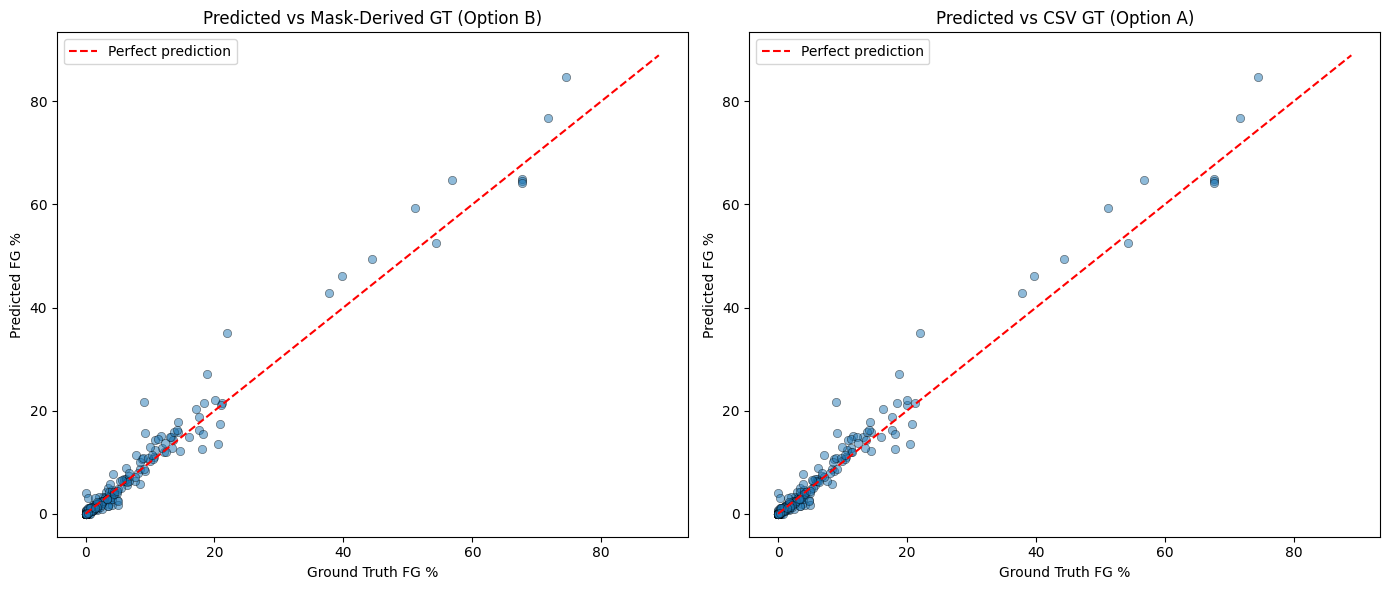

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (gt, label) in zip(axes, [
    (gt_pcts_mask, "Mask-Derived GT (Option B)"),
    (gt_pcts_csv,  "CSV GT (Option A)"),
]):
    ax.scatter(gt, pred_pcts, alpha=0.5, edgecolors='k', linewidths=0.5)
    lim_max = max(gt.max(), pred_pcts.max()) * 1.05
    ax.plot([0, lim_max], [0, lim_max], 'r--', label='Perfect prediction')
    ax.set_xlabel("Ground Truth FG %")
    ax.set_ylabel("Predicted FG %")
    ax.set_title(f"Predicted vs {label}")
    ax.legend()

plt.tight_layout()
plt.show()

### Per-sample worst predictions (highest MAE rows)

In [186]:
per_sample = test_df.copy().reset_index(drop=True)
per_sample["pred_fg_pct"]  = pred_pcts
per_sample["gt_fg_pct"]    = gt_pcts_mask
per_sample["csv_fg_pct"]   = gt_pcts_csv
per_sample["abs_error"]    = np.abs(pred_pcts - gt_pcts_mask)

worst_k = 10
worst_df = per_sample.nlargest(worst_k, "abs_error")[[
    "image_name", "gt_fg_pct", "csv_fg_pct", "pred_fg_pct", "abs_error"
]].reset_index(drop=True)

print(f"Top-{worst_k} worst predictions (by absolute error on mask-derived GT):")
worst_df

Top-10 worst predictions (by absolute error on mask-derived GT):


,image_name,gt_fg_pct,csv_fg_pct,pred_fg_pct,abs_error
0,img1228.jpg,21.962334,21.97,35.092915,13.130581
1,img1220.jpg,8.998047,9.00,21.648716,12.650669
2,img1460.jpg,74.477402,74.47,84.698380,10.220978
3,img1320.jpg,18.784040,18.79,27.082590,8.298550
4,img1205.jpg,51.143135,51.14,59.254189,8.111053
5,img1430.jpg,56.769253,56.75,64.784599,8.015347
6,img1336.jpg,20.505581,20.50,13.525112,6.980469
7,img1318.jpg,9.156528,9.17,15.638950,6.482422
8,img1208.jpg,39.771484,39.77,46.185547,6.414062
9,img1337.jpg,18.133371,18.13,12.617466,5.515905


### Inferences

In [188]:
def denormalize_image(image_tensor, mean, std):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = image * np.array(std) + np.array(mean)
    image = np.clip(image, 0, 1)
    return image

def show_predictions(model, dataset, device, threshold=0.5, num_samples=5):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    plt.figure(figsize=(15, num_samples * 5))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]

            input_tensor = image.unsqueeze(0).to(device)
            logits = model(input_tensor)
            probs = torch.sigmoid(logits)
            pred = (probs > threshold).float()

            image_np = denormalize_image(image, mean, std)
            mask_np = mask.squeeze(0).cpu().numpy()
            pred_np = pred.squeeze().cpu().numpy()

            plt.subplot(num_samples, 3, i * 3 + 1)
            plt.imshow(image_np)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 2)
            plt.imshow(mask_np, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 3)
            plt.imshow(pred_np, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

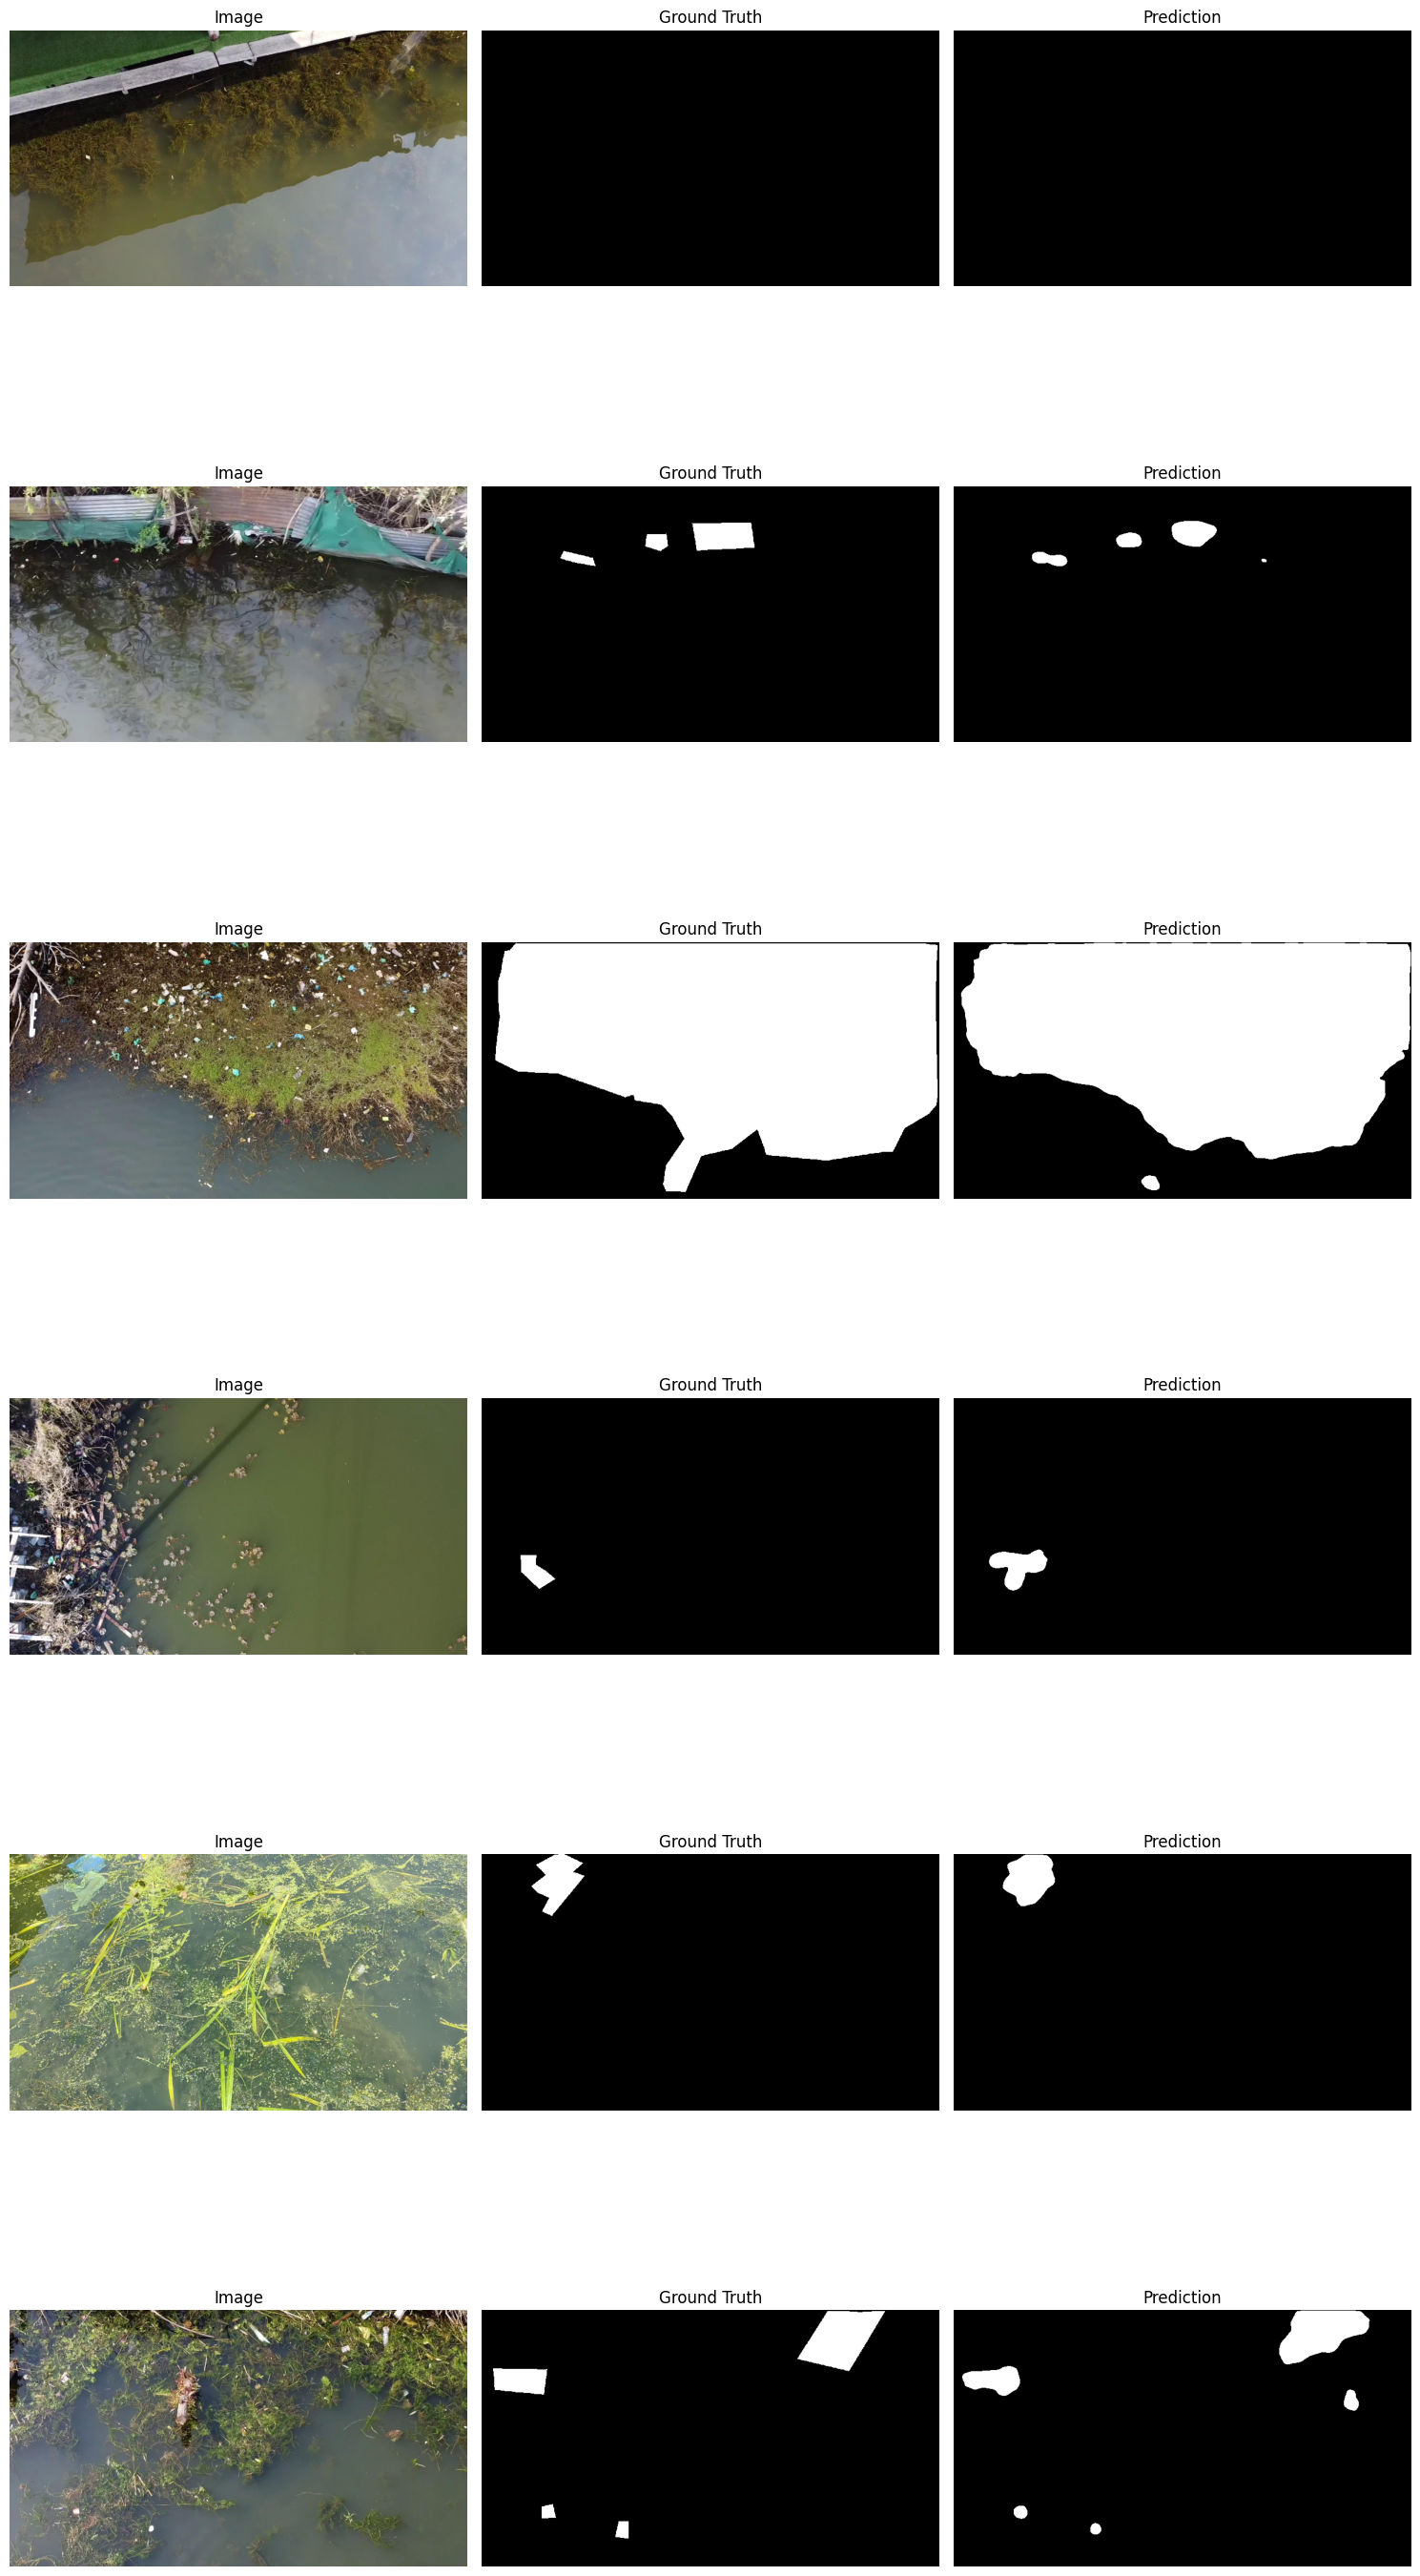

In [189]:
show_predictions(model, test_dataset, DEVICE, threshold=best_threshold, num_samples=6)